In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from tqdm import tqdm
from pathlib import Path
from datetime import datetime

In [ ]:
file_ext  = '.txt'
file_name = '1. well a'
file_type = 'geothermal'

base_path = os.path.dirname(os.getcwd()).split(os.sep)[:-1]
base_path = f'{os.sep}'.join(base_path)
data_path = os.path.join(base_path, 'datasets', file_type, file_name)

In [3]:
#-- get all ascii data path
def get_ascii_file_path(file_ext = '.txt'):
    directories = list()

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file_ext not in file:
                continue
                
            full_path = os.path.join(root, file)
            directories.append(full_path)

    return directories

In [4]:
#-- get ascii format [NOTE: hardcoded, adjust manually!]
def get_ascii_format(date_text):
    default = {
        'date_time'    : len('            Date-Time '),
        'log_depth'    : len('LogDepth '),
        'bit_depth'    : len('BitDepth '),
        'block_pos'    : len('BlockPos '),
        'wob'          : len('   WOB '),
        'tob'          : len('  TOB '),
        'torquep'      : len('Torquep '),
        'torque'       : len('Torque '),
        'hkld'         : len('  Hkld '),
        'rpm'          : len('RPM '),
        'ropi'         : len('  ROPi '),
        'mse'          : len('    MSE '),
        'sppress'      : len('SpPress '),
        'totspm'       : len('TotSPM '),
        'mudflowin'    : len('MudFlowIn '),
        'mudflowoutp'  : len('MudFlowOutp '),
        'mudtempin'    : len('MudTempIn '),
        'mudtempout'   : len('MudTempOut '),
        'tankvoltot'   : len('TankVolTot '),
        'gas'          : len('Gas '),
        'bvdepth'      : len('BVDepth '),
        'binclination' : len('BInclination '),
        'bazimuth'     : len('BAzimuth '),
        'dazimuth'     : len('DAzimuth '),
        'dinclination' : len('DInclination '),
        'dvdepth'      : len('DVDepth')
    }

    if date_text == '2024-05-26_2024-06-01':
        default['mse'] = len('     MSE ')

    if date_text == '2024-06-01_2024-06-08':
        default['rpm'] = len(' RPM ')
        default['mse'] = len('     MSE ')

    if date_text == '2024-06-09_2024-06-12':
        default['mse']  = len('  MSE ')
        
    return default 

In [5]:
files = get_ascii_file_path()

print(f'{len(files)} ascii data found')

5 ascii data found


In [6]:
for path in files:
    file   = open(path)
    data   = [p.replace('\n', '') for p in file.readlines()]
    header = data[0]
    data   = data[2:] 
    
    print(f'{path} : {len(header)}')
    
    file.close()

E:\Jupyter\manannan\stuck-prediction-v2\datasets\geothermal\1. KMJ-69.4\2024-05-11_2024-05-18.txt : 235
E:\Jupyter\manannan\stuck-prediction-v2\datasets\geothermal\1. KMJ-69.4\2024-05-19_2024-05-25.txt : 235
E:\Jupyter\manannan\stuck-prediction-v2\datasets\geothermal\1. KMJ-69.4\2024-05-26_2024-06-01.txt : 236
E:\Jupyter\manannan\stuck-prediction-v2\datasets\geothermal\1. KMJ-69.4\2024-06-02_2024-06-08.txt : 237
E:\Jupyter\manannan\stuck-prediction-v2\datasets\geothermal\1. KMJ-69.4\2024-06-09_2024-06-12.txt : 233


In [7]:
tmp_data = list()

for path in tqdm(files):
    #-- read file path
    file = open(path)
    data = [p.replace('\n', '') for p in file.readlines()]

    #- get metadata and header
    header  = data[0]
    data    = data[2:]
    columns = get_ascii_format(Path(path).stem)
    
    for line in data:
        tmp_line = dict()
        start, end = 0, 0
        
        for key, value in columns.items():
            #-- walking index pointer 
            if start != 0:
                end += value
            else:
                end = value
    
            #-- retrieve and preprocsess data
            tmp_val = line[start:end]
            if start == 0:
                tmp_val = tmp_val[:len(tmp_val)-1]
            else:  
                if tmp_val.isspace() or tmp_val == '':
                    tmp_val = '0'
                else:   
                    tmp_val = tmp_val.replace(' ', '')
    
            #-- store data and adjust pointer
            tmp_line[key] = tmp_val
            start += value

        tmp_data.append(tmp_line)
        
    file.close()

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:26<00:00,  5.28s/it]


In [8]:
df = pd.DataFrame(tmp_data)
df.shape

(559414, 26)

In [9]:
df[df.columns[0]]  = pd.to_datetime(df[df.columns[0]])
df[df.columns[1:]] = df[df.columns[1:]].astype(float) 

df.sort_values(by = df.columns[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559414 entries, 0 to 559413
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_time     559414 non-null  datetime64[ns]
 1   log_depth     559414 non-null  float64       
 2   bit_depth     559414 non-null  float64       
 3   block_pos     559414 non-null  float64       
 4   wob           559414 non-null  float64       
 5   tob           559414 non-null  float64       
 6   torquep       559414 non-null  float64       
 7   torque        559414 non-null  float64       
 8   hkld          559414 non-null  float64       
 9   rpm           559414 non-null  float64       
 10  ropi          559414 non-null  float64       
 11  mse           559414 non-null  float64       
 12  sppress       559414 non-null  float64       
 13  totspm        559414 non-null  float64       
 14  mudflowin     559414 non-null  float64       
 15  mudflowoutp   559

In [10]:
df[df.columns[0]].head()

0   2024-05-11 00:00:00
1   2024-05-11 00:00:05
2   2024-05-11 00:00:10
3   2024-05-11 00:00:15
4   2024-05-11 00:00:20
Name: date_time, dtype: datetime64[ns]

In [11]:
df[df.columns[0]].tail()

559409   2024-06-12 08:58:30
559410   2024-06-12 08:58:35
559411   2024-06-12 08:58:40
559412   2024-06-12 08:58:45
559413   2024-06-12 08:58:50
Name: date_time, dtype: datetime64[ns]

In [12]:
#-- stuck labels
pattern = "%Y-%m-%d %H:%M:%S"
labels  = [
    (datetime.strptime('2024-06-07 10:12:20', pattern), datetime.strptime('2024-06-07 20:02:55', pattern))
]

In [13]:
df['stuck'] = 0

for start, end in tqdm(labels):
    df.loc[df[df.columns[0]].between(start, end), 'stuck'] = 1

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 87.07it/s]


In [14]:
#-- interrupted time series
interrupted  = [
    (datetime.strptime('2024-06-07 12:00:00', pattern), datetime.strptime('2024-06-07 14:30:00', pattern))
]

In [15]:
for start, end in tqdm(interrupted):
    df.loc[df[df.columns[0]].between(start, end), 'stuck'] = 0

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 106.37it/s]


In [16]:
df['stuck'].value_counts(normalize=True) * 100

stuck
0    99.054904
1     0.945096
Name: proportion, dtype: float64

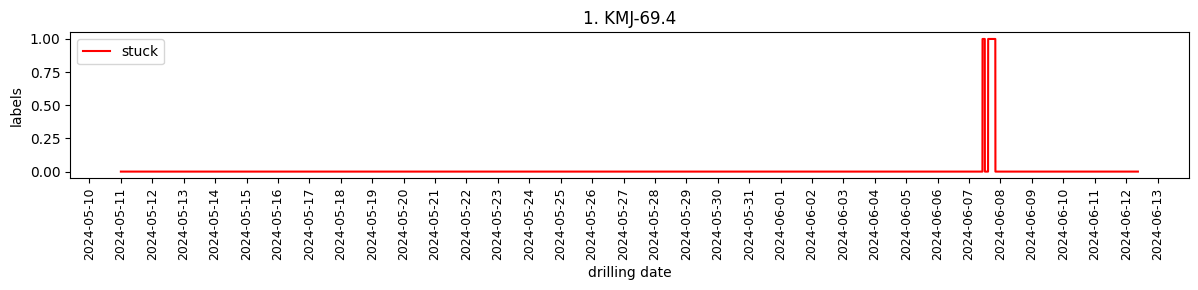

In [17]:
fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(df[df.columns[0]], df['stuck'], label='stuck', color='red')

ax.set_title(file_name)
ax.set_xlabel('drilling date')
ax.set_ylabel('labels')
ax.legend(loc='upper left')

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.show()

In [18]:
file_path = os.path.join(base_path, 'datasets_ready', f'{file_name}.csv')
df.to_csv(file_path, index=False)